# Logistic Regression, Perceptron & Multi-class Wrap (Từ đầu)
Báo cáo chi tiết các phần thực nghiệm chạy các giải thuật Core từ zero.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *
from sklearn.metrics import accuracy_score

# Đọc tập dữ liệu đã chuẩn hóa
train_df = pd.read_csv('../../data/classification/processed/dry_bean/train_scaled.csv')
val_df = pd.read_csv('../../data/classification/processed/dry_bean/val_scaled.csv')
test_df = pd.read_csv('../../data/classification/processed/dry_bean/test_scaled.csv')

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values
X_val = val_df.iloc[:, :-1].values
y_val = val_df.iloc[:, -1].values
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (9480, 16), Test size: (2032, 16)


## 1. Biểu thức toán học Logistic Regression
### Gradient và Hessian:
- Gradient của Softmax (cross-entropy direct multinomial): $\nabla E = \frac{1}{N} \sum_{n=1}^N (\mathbf{y}_n - \mathbf{t}_n)\mathbf{x}_n^T$ 
- Hessian cho Binary LR (để tính Newton-Raphson): $H = \Phi^T R \Phi$ nơi $R = diag(y_n(1 - y_n))$.
Việc sử dụng phương pháp **Newton-Raphson (IRLS)** tốn nhiều chi phí vì thao tác nghịch đảo ma trận $H$ kích thước $(D+1, D+1)$, dẫn đến giới hạn của việc huấn luyện trên tập Features siêu đa chiều.

## 2. Thí nghiệm Binary: Gradient Descent vs Newton-Raphson
Gián lược bài toán K=7 thành Binary thông qua việc lọc 2 loại đậu phổ biến nhất là DERMASON (5) và SIRA (6) để quan sát hội tụ Hessian và Gradient.

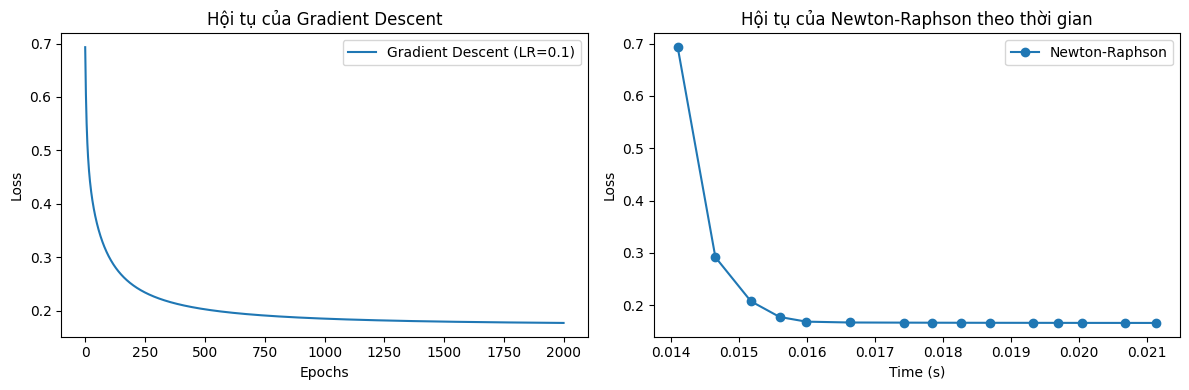

Accuracy Gradient Descent: 0.9266
Accuracy Newton-Raphson: 0.9310


In [3]:
# Lọc mẫu 2 class
mask_train = (y_train == 'DERMASON') | (y_train == 'SIRA')
mask_val = (y_val == 'DERMASON') | (y_val == 'SIRA')

X_bin_train, y_bin_train = X_train[mask_train], y_train[mask_train]
X_bin_val, y_bin_val = X_val[mask_val], y_val[mask_val]

# Convert nhãn về 0 và 1 (SIRA -> 1, DERMASON -> 0)
y_bin_train = (y_bin_train == 'SIRA').astype(int)
y_bin_val = (y_bin_val == 'SIRA').astype(int)

# Model 1: Gradient Descent
model_gd = LogisticRegressionGD(learning_rate=0.1, max_epochs=2000)
model_gd.fit(X_bin_train, y_bin_train)

# Model 2: Newton-Raphson
model_nt = LogisticRegressionNewton(max_epochs=15, tol=1e-5)
model_nt.fit(X_bin_train, y_bin_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# Loss vs Epoch for GD
ax1.plot(model_gd.loss_history, label='Gradient Descent (LR=0.1)')
ax1.set_title("Hội tụ của Gradient Descent")
ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss")
ax1.legend()

# Loss vs Time for Newton-Raphson
ax2.plot(model_nt.wall_clock_time, model_nt.loss_history, marker='o', label='Newton-Raphson')
ax2.set_title("Hội tụ của Newton-Raphson theo thời gian")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Loss")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"Accuracy Gradient Descent: {accuracy_score(y_bin_val, model_gd.predict(X_bin_val)):.4f}")
print(f"Accuracy Newton-Raphson: {accuracy_score(y_bin_val, model_nt.predict(X_bin_val)):.4f}")

## 3. Thí nghiệm Multi-class (7 Classes): OVR, OVO, Softmax
Thực chiến lại độ hiệu quả thuật toán trực tiếp trên toàn bộ dữ liệu 7 lớp gốc kết hợp với base module (Binary Gradient Descent).
`OneVsOne` (OVO) sẽ tiêu tốn thời gian hơn đáng kể vì đòi hỏi phải training tới $\frac{7 \times 6}{2} = 21$ networks độc lập.

In [4]:
import time

base_lr = LogisticRegressionGD(learning_rate=0.1, max_epochs=500)

print("Training One-Vs-Rest...")
ovr_model = OneVsRestClassifier(estimator=base_lr)
t_start = time.time(); ovr_model.fit(X_train, y_train); t_ovr = time.time() - t_start

print("Training One-Vs-One...")
ovo_model = OneVsOneClassifier(estimator=base_lr)
t_start = time.time(); ovo_model.fit(X_train, y_train); t_ovo = time.time() - t_start

print("Training Softmax (Multinomial direct)...")
softmax_model = LogisticRegressionGD(learning_rate=0.1, max_epochs=500, multi_class='multinomial')
t_start = time.time(); softmax_model.fit(X_train, y_train); t_soft = time.time() - t_start

acc_ovr = accuracy_score(y_val, ovr_model.predict(X_val))
acc_ovo = accuracy_score(y_val, ovo_model.predict(X_val))
acc_soft = accuracy_score(y_val, softmax_model.predict(X_val))

results = pd.DataFrame({
    'Strategy': ['OVR', 'OVO', 'Softmax'],
    'Accuracy': [acc_ovr, acc_ovo, acc_soft],
    'Time (s)': [t_ovr, t_ovo, t_soft]
})
results

Training One-Vs-Rest...
Training One-Vs-One...
Training Softmax (Multinomial direct)...


,Strategy,Accuracy,Time (s)
0,OVR,0.848351,1.099448
1,OVO,0.908912,1.164830
2,Softmax,0.887740,1.009594


## 4. Thuật toán Perceptron Nhị phân
Chạy thuật toán học mạng nơ-ron nền tảng cho bài toán nhị phân. Đôi khi thuật toán có thể không hội tụ tuyệt đối nếu lớp dữ liệu có đường lằn nhiễu không chia cắt tuyến tính được.

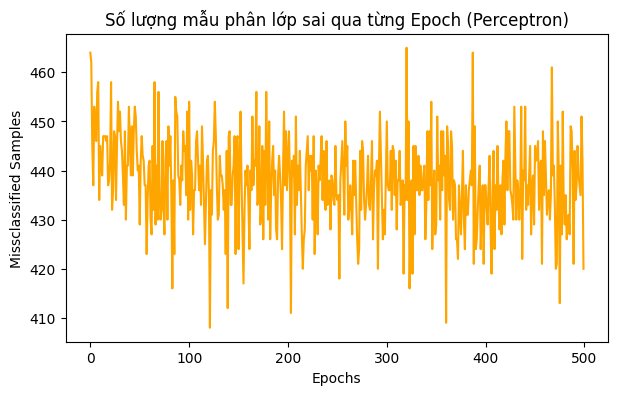

Perceptron Validation Accuracy: 0.8652


In [5]:
perceptron = Perceptron(learning_rate=0.01, max_epochs=500)
perceptron.fit(X_bin_train, y_bin_train)

plt.figure(figsize=(7,4))
plt.plot(perceptron.errors_history, color='orange')
plt.title("Số lượng mẫu phân lớp sai qua từng Epoch (Perceptron)")
plt.xlabel("Epochs")
plt.ylabel("Missclassified Samples")
plt.show()

print(f"Perceptron Validation Accuracy: {accuracy_score(y_bin_val, perceptron.predict(X_bin_val)):.4f}")

## 5. Logistic Regression có L1 / L2 Regularization & Class Weight
Để tăng tính bền vững (Robustness) và tránh Overfitting, ta khảo sát độ lớn trọng số rải rác (Sparsity weights) khi đưa parameter penalty lambda vào.

<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\TRAN DAT\AppData\Local\Temp\ipykernel_10012\3135763783.py:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Độ lớn các trọng số $\mathbf{w}$ (Sparsity) theo phương pháp Regularization")


Accuracy Không Penalty     : 0.9202
Accuracy L2 (class_weighted): 0.9234
Accuracy L1 (class_weighted): 0.9223


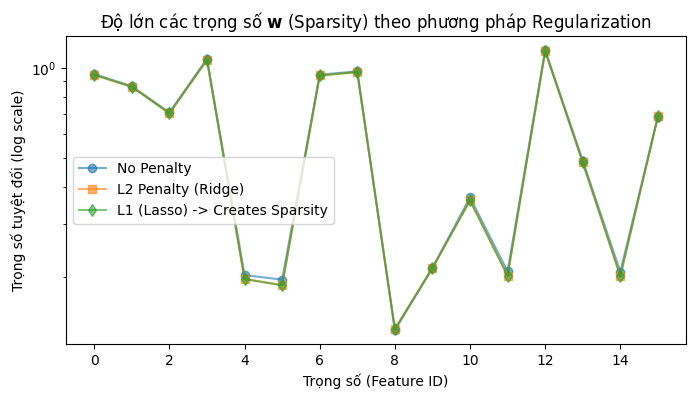

In [6]:
# Base Model không cần penalty so sánh với L1, L2
lr_no_pen = LogisticRegressionReg(learning_rate=0.1, penalty='l2', C=0.0, max_epochs=500)
lr_no_pen.fit(X_bin_train, y_bin_train)

# Class weight='balanced' giúp mô hình cân bằng tốt hơn loss khi lớp dữ liệu mất cân bằng sample. 
# Tham số C là hằng số ngược của Lambda trong phương trình chính quy hóa.
lr_l2 = LogisticRegressionReg(learning_rate=0.1, penalty='l2', C=10.0, max_epochs=500, class_weight='balanced')
lr_l2.fit(X_bin_train, y_bin_train)

lr_l1 = LogisticRegressionReg(learning_rate=0.1, penalty='l1', C=20.0, max_epochs=500, class_weight='balanced')
lr_l1.fit(X_bin_train, y_bin_train)

print(f"Accuracy Không Penalty     : {accuracy_score(y_bin_val, lr_no_pen.predict(X_bin_val)):.4f}")
print(f"Accuracy L2 (class_weighted): {accuracy_score(y_bin_val, lr_l2.predict(X_bin_val)):.4f}")
print(f"Accuracy L1 (class_weighted): {accuracy_score(y_bin_val, lr_l1.predict(X_bin_val)):.4f}")

# Vẽ phân bố Weights (Sparsity)
plt.figure(figsize=(8, 4))
plt.plot(np.abs(lr_no_pen.w[1:]), 'o-', label='No Penalty', alpha=0.6)
plt.plot(np.abs(lr_l2.w[1:]), 's-', label='L2 Penalty (Ridge)', alpha=0.6)
plt.plot(np.abs(lr_l1.w[1:]), 'd-', label='L1 (Lasso) -> Creates Sparsity', alpha=0.6)
plt.title("Độ lớn các trọng số $\mathbf{w}$ (Sparsity) theo phương pháp Regularization")
plt.yscale("log")
plt.ylabel("Trọng số tuyệt đối (log scale)")
plt.xlabel("Trọng số (Feature ID)")
plt.legend()
plt.show()

## 6. [Bonus Nâng Cao] Mô hình Probit và Xấp xỉ Laplace (Laplace Approximation)
- **Probit Regression**: Sử dụng hàm xác suất tích lũy (CDF Gaussian chuẩn $\Phi(z)$) để thay cho đường cong Sigmoid $\sigma(z)$. Phù hợp xử lý dữ liệu nơi phân chia bị nhiễu.
- **Xấp xỉ Laplace**: Giải quyết bài toán Maximum A Posteriori (MAP) phân phối Hậu nghiệm cho Logistic Regression, sau đó tính ma trận hiệp phương sai của xác suất Posterior dựa vào nghịch đảo Hessian $H^{-1}$. Xấp xỉ Laplace có lợi thế khi đi kèm tính toán khoảng bất định (Uncertainty Margin). Nó bớt sai dại tự tin cho điểm sample nằm ở vùng quyết định mơ hồ.

Accuracy Probit Regression  : 0.9266
Accuracy Laplace Approxi.   : 0.9288


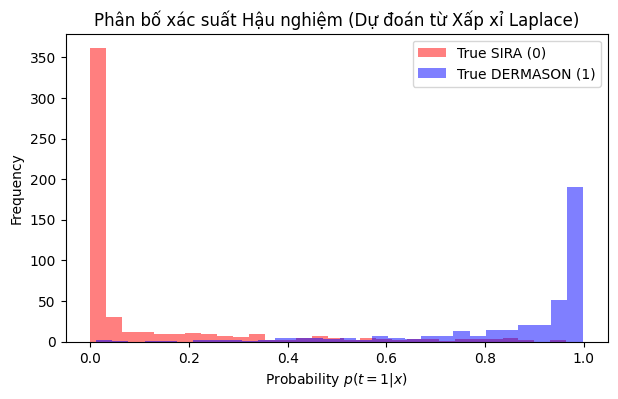

In [7]:
# 1. Probit Regression
probit = ProbitRegressionGD(learning_rate=0.1, max_epochs=1000)
probit.fit(X_bin_train, y_bin_train)
acc_probit = accuracy_score(y_bin_val, probit.predict(X_bin_val))

# 2. Laplace Approximation
laplace = LaplaceApproximationLR(lambd=1.0, max_epochs=50)
laplace.fit(X_bin_train, y_bin_train)
acc_laplace = accuracy_score(y_bin_val, laplace.predict(X_bin_val))

prob_pred_laplace = laplace.predict_proba(X_bin_val)[:, 1]

print(f"Accuracy Probit Regression  : {acc_probit:.4f}")
print(f"Accuracy Laplace Approxi.   : {acc_laplace:.4f}")

plt.figure(figsize=(7, 4))
plt.hist(prob_pred_laplace[y_bin_val==0], bins=30, alpha=0.5, label='True SIRA (0)', color='red')
plt.hist(prob_pred_laplace[y_bin_val==1], bins=30, alpha=0.5, label='True DERMASON (1)', color='blue')
plt.title("Phân bố xác suất Hậu nghiệm (Dự đoán từ Xấp xỉ Laplace)")
plt.xlabel("Probability $p(t=1 | x)$")
plt.ylabel("Frequency")
plt.legend()
plt.show()